# Item-by-item look: what drives the Bogotá-Medellín basket gap?

For each of the 10 selected fresh foods we subtract the Medellín (CMA) wholesale price from the Bogotá (Corabastos) price on each of the four sampled dates.

**Positive = the food cost more in Bogotá on that date.**

Source: official DANE/SIPSA daily workbooks, wholesale COP/kg. This is a fresh-food market-price proxy, not an official retail Cost of a Healthy Diet estimate.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# This env's freetype (2.14.2) raster-overflows when matplotlib rasterizes glyphs
# to PNG. SVG embeds font outlines instead, so it sidesteps the bug and is sharper.
# Remove this line once the environment is fixed (see the note at the end).
%config InlineBackend.figure_formats = ["svg"]

PROJECT_ROOT = Path.cwd()
GAP_FILE = PROJECT_ROOT / "data" / "processed" / "food_price_gap_by_item.csv"
TOTALS_FILE = PROJECT_ROOT / "data" / "processed" / "reference_basket_totals.csv"

GAP = "bogota_minus_medellin_cop_per_kg"

gaps = pd.read_csv(GAP_FILE, parse_dates=["date"])
totals = pd.read_csv(TOTALS_FILE, parse_dates=["date"])

gaps.head()

,date,item,food_group,bogota_cop_per_kg,medellin_cop_per_kg,bogota_minus_medellin_cop_per_kg,higher_price_market
0,2025-02-12,Aguacate,Fruit,8688.0,6550.0,2138.0,Bogotá
1,2025-02-12,Chócolo mazorca,Vegetables,2900.0,1458.0,1442.0,Bogotá
2,2025-02-12,Zanahoria,Vegetables,2177.0,1022.0,1155.0,Bogotá
3,2025-02-12,Ahuyama,Vegetables,1675.0,1025.0,650.0,Bogotá
4,2025-02-12,Banano,Fruit,2925.0,2275.0,650.0,Bogotá


## Check the table before trusting it

Every food should appear on every date with no missing prices, and the item-level gaps should add up to the basket-level gap. If that second check fails, the item table and the basket totals were built from different price data.

In [2]:
print(f"rows: {len(gaps)}  items: {gaps['item'].nunique()}  dates: {gaps['date'].nunique()}")
print(f"missing values: {int(gaps.isna().sum().sum())}")
print(f"complete item x date grid: {len(gaps) == gaps['item'].nunique() * gaps['date'].nunique()}")

basket = totals.pivot(index="date", columns="city", values="equal_weight_reference_basket_cop")
reconciliation = pd.DataFrame(
    {
        "sum_of_item_gaps": gaps.groupby("date")[GAP].sum(),
        "basket_total_gap": basket["Bogotá"] - basket["Medellín"],
    }
)
reconciliation["matches"] = (
    reconciliation["sum_of_item_gaps"] - reconciliation["basket_total_gap"]
).abs() < 1
reconciliation

rows: 40  items: 10  dates: 4
missing values: 0
complete item x date grid: True


,sum_of_item_gaps,basket_total_gap,matches
date,,,
2025-02-12,4955.0,4955.0,True
2025-05-14,3120.0,3120.0,True
2025-08-13,4416.0,4416.0,True
2025-11-12,5923.0,5923.0,True


## The full item-by-item table

Foods are ordered by their average gap across the four dates, and that ordering is reused everywhere below.

In [3]:
wide = gaps.pivot(index="item", columns="date", values=GAP)
wide.columns = [d.strftime("%d %b %Y") for d in wide.columns]
wide["average"] = wide.mean(axis=1)
wide = wide.sort_values("average", ascending=False)

item_order = list(wide.index)
wide.round(0).astype(int)

,12 Feb 2025,14 May 2025,13 Aug 2025,12 Nov 2025,average
item,,,,,
Aguacate,2138,300,1363,325,1032
Zanahoria,1155,839,2299,-167,1032
Ahuyama,650,950,1163,950,928
Chócolo mazorca,1442,-217,-308,1933,712
Banano,650,925,363,550,622
Guayaba,-187,1834,-749,1420,580
Yuca,151,-189,269,673,226
Tomate,-497,70,380,431,96
Cebolla cabezona blanca,-297,-548,-102,-173,-280


### How consistent is each food?

`dates_bogota_higher` counts how many of the four dates the food was more expensive in Bogotá. A food with a large average gap but a low count is a spiker, not a persistent difference.

In [4]:
profile = (
    gaps.groupby(["item", "food_group"])
    .agg(
        average_gap=(GAP, "mean"),
        min_gap=(GAP, "min"),
        max_gap=(GAP, "max"),
        dates_bogota_higher=(GAP, lambda s: int((s > 0).sum())),
    )
    .reset_index()
    .sort_values("average_gap", ascending=False)
)
profile["swing"] = profile["max_gap"] - profile["min_gap"]
profile.round(0)

,item,food_group,average_gap,min_gap,max_gap,dates_bogota_higher,swing
0,Aguacate,Fruit,1032.0,300.0,2138.0,4,1838.0
9,Zanahoria,Vegetables,1032.0,-167.0,2299.0,3,2466.0
1,Ahuyama,Vegetables,928.0,650.0,1163.0,4,513.0
4,Chócolo mazorca,Vegetables,712.0,-308.0,1933.0,2,2241.0
2,Banano,Fruit,622.0,363.0,925.0,4,562.0
5,Guayaba,Fruit,580.0,-749.0,1834.0,2,2583.0
8,Yuca,Tubers and plantains,226.0,-189.0,673.0,3,862.0
7,Tomate,Vegetables,96.0,-497.0,431.0,3,928.0
3,Cebolla cabezona blanca,Vegetables,-280.0,-548.0,-102.0,0,446.0
6,Naranja,Fruit,-344.0,-844.0,-19.0,0,825.0


### Share of each date's basket gap

The same gap in COP/kg matters more on a date when the overall basket gap is small, so read each contribution as a share of that date's total gap.

In [5]:
shares = gaps.copy()
shares["share_of_date_gap_pct"] = (
    100 * shares[GAP] / shares.groupby("date")[GAP].transform("sum")
)
share_wide = shares.pivot(index="item", columns="date", values="share_of_date_gap_pct")
share_wide.columns = [d.strftime("%d %b %Y") for d in share_wide.columns]
share_wide.loc[item_order].round(1)

,12 Feb 2025,14 May 2025,13 Aug 2025,12 Nov 2025
item,,,,
Aguacate,43.1,9.6,30.9,5.5
Zanahoria,23.3,26.9,52.1,-2.8
Ahuyama,13.1,30.4,26.3,16.0
Chócolo mazorca,29.1,-7.0,-7.0,32.6
Banano,13.1,29.6,8.2,9.3
Guayaba,-3.8,58.8,-17.0,24.0
Yuca,3.0,-6.1,6.1,11.4
Tomate,-10.0,2.2,8.6,7.3
Cebolla cabezona blanca,-6.0,-17.6,-2.3,-2.9


## Small multiples: one panel per sampled date

A diverging bar chart is the right form because the sign carries the meaning. Red bars point right (Bogotá more expensive), blue bars point left (Medellín more expensive), and the neutral zero line is the reference. Item order is held fixed across all four panels, so a bar flipping sides is visible at a glance.

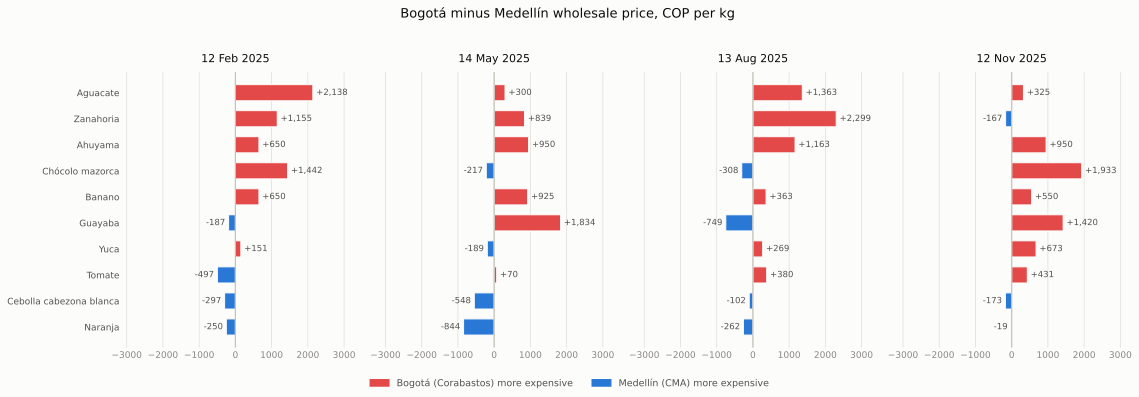

In [6]:
# Diverging pair from the reference palette: warm/cool poles, neutral gray midpoint.
BOGOTA_HIGHER = "#e34948"
MEDELLIN_HIGHER = "#2a78d6"
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
BASELINE = "#c3c2b7"
GRIDLINE = "#e1e0d9"

dates = sorted(gaps["date"].unique())
limit = gaps[GAP].abs().max() * 1.35

fig, axes = plt.subplots(1, len(dates), figsize=(16, 5.5), sharey=True)
fig.patch.set_facecolor(SURFACE)

for ax, date in zip(axes, dates):
    # Reversed so the largest average gap sits at the top of the axis.
    panel = gaps[gaps["date"] == date].set_index("item").loc[item_order[::-1]]
    colors = [BOGOTA_HIGHER if v > 0 else MEDELLIN_HIGHER for v in panel[GAP]]

    ax.set_facecolor(SURFACE)
    ax.barh(
        panel.index,
        panel[GAP],
        height=0.62,
        color=colors,
        edgecolor=SURFACE,
        linewidth=1.0,
        zorder=3,
    )

    # Values are direct-labeled because a static chart has no hover layer to fall back on.
    for y, value in enumerate(panel[GAP]):
        offset = limit * 0.03
        ax.text(
            value + (offset if value >= 0 else -offset),
            y,
            f"{value:+,.0f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=8.5,
            color=INK_SECONDARY,
        )

    ax.axvline(0, color=BASELINE, linewidth=1.2, zorder=4)
    ax.set_xlim(-limit, limit)
    ax.set_title(pd.Timestamp(date).strftime("%d %b %Y"), fontsize=11, color=INK_PRIMARY, pad=10)
    ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=9, colors=INK_MUTED, length=0)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

axes[0].tick_params(axis="y", labelsize=9, colors=INK_SECONDARY)

# Legend so the sign is never carried by color alone.
handles = [
    plt.Rectangle((0, 0), 1, 1, color=BOGOTA_HIGHER),
    plt.Rectangle((0, 0), 1, 1, color=MEDELLIN_HIGHER),
]
fig.legend(
    handles,
    ["Bogotá (Corabastos) more expensive", "Medellín (CMA) more expensive"],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9.5,
    labelcolor=INK_SECONDARY,
)
fig.suptitle(
    "Bogotá minus Medellín wholesale price, COP per kg",
    fontsize=13,
    color=INK_PRIMARY,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()

## Top three drivers on each date

In [7]:
value_columns = [GAP, "share_of_date_gap_pct"]
top_drivers = (
    shares.sort_values(["date", GAP], ascending=[True, False])
    .groupby("date")
    .head(3)
    .loc[:, ["date", "item", "food_group", *value_columns]]
    .reset_index(drop=True)
)
top_drivers[value_columns] = top_drivers[value_columns].round(1)
top_drivers

,date,item,food_group,bogota_minus_medellin_cop_per_kg,share_of_date_gap_pct
0,2025-02-12,Aguacate,Fruit,2138.0,43.1
1,2025-02-12,Chócolo mazorca,Vegetables,1442.0,29.1
2,2025-02-12,Zanahoria,Vegetables,1155.0,23.3
3,2025-05-14,Guayaba,Fruit,1834.0,58.8
4,2025-05-14,Ahuyama,Vegetables,950.0,30.4
5,2025-05-14,Banano,Fruit,925.0,29.6
6,2025-08-13,Zanahoria,Vegetables,2299.0,52.1
7,2025-08-13,Aguacate,Fruit,1363.0,30.9
8,2025-08-13,Ahuyama,Vegetables,1163.0,26.3
9,2025-11-12,Chócolo mazorca,Vegetables,1933.0,32.6


## Reading this

Bogotá's basket is higher on all four dates, but no single food explains it. The largest contributor rotates across dates, and some foods flip sides entirely. That rotation is the finding worth reporting: a national annual average would flatten it away.

This is descriptive, not causal. Four sampled dates cannot separate harvest timing, transport cost, local supply, or quality differences between the two markets.

---

### Environment note

Charts in this environment cannot render to PNG. Any matplotlib text raises `RuntimeError: FT_Render_Glyph ... raster overflow`, even for an empty string, because a pip-installed matplotlib is picking up conda-forge's `freetype 2.14.2`. The SVG config in the first cell works around it.

To fix it properly, pick one:

```
pip install --force-reinstall --no-cache-dir matplotlib   # use matplotlib's own bundled freetype
conda install "freetype<2.14"                             # downgrade the conda library
```

Also worth cleaning up: `conda list` reports matplotlib 3.10.9 while the imported version is 3.11.0, so it is installed twice (conda and pip) in this env.